In [1]:
import pandas as pd
import numpy as np
import prepare_data
import os
import stability

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.inspection import permutation_importance
import lightgbm as lgb

## To test the stability of our analysis, we will introduce perturbations in our original training data and evaluate across the entire data science pipeline

One way to perturb image data is to introduce statistical noise to the existing features. Two common examples of noise are Gaussian noise and  impulse noise. Gaussian noise impacts all pixels in the perturbed image by introducing low-level variations (following a normal distribution) to features. Impulse noise corrupts small subsets of pixels with extreme values. 

## Gaussian noise

We define a function to introduce gaussian noise to a single feature. 
The input parameters are the original pandas dataframe (Training image), the feature, and parameters of the normal distribution (mean and standard deviation). 

In [2]:
def gauss_noise(df, features, mu=0, sigma=0.1): 
    df_noisy = df.copy()
    for feat in features: 
        df_noisy[feat] = df_noisy[feat] + np.random.normal(mu, sigma, size=len(df_noisy))
    return df_noisy

## Impulse noise

We define a function to introduce impulse noise across a feature of the  training image. The noise_level is the proportion of data points to be altered [0, 1]. The impulse_magnitude (which can be a float or a function) is the value / range of values for the impulses. 

In [3]:
def impulse_noise(df, feature, noise_level, impulse_magnitude): 
    df_noisy = df.copy()
    num_noisy_pixels = int(noise_level * len(df))

    for i in len(df): 
        if callable(impulse_magnitude):         # if magnitude is a fxn
            df_noisy[i] = impulse_magnitude()
        else: 
            df_noisy[i] = impulse_magnitude     # if magnitude is a float
    
    return df_noisy

## Now we will go through the entire data pipeline introducing gaussian noise

Gaussian noise will be introduced to the original radiance data of the training image (before cleaning). In general, noise is only applied to the training data to improve robustness and avoid overfitting. Because our pipeline takes the initial npz file, the file will have to be loaded, then noise applied, and converted back to npz file. 

Will use the same image for training as decided in previous iterations

In [4]:
file_path = '../data/O013490.npz'
with np.load(file_path) as data: 
    target_array = data['arr_0']

In [5]:
train = pd.DataFrame(target_array[:,0:11], 
                       columns=['y', 'x', 'ndai', 'sd', 'corr', 
                       'df', 'cf', 'bf', 'af', 'an', 'label'])
train.head()

,y,x,ndai,sd,corr,df,cf,bf,af,an,label
0,2.0,70.0,0.464717,559.852661,0.102706,30504.75,24295.25,17605.50,13117.00,11148.00,1.0
1,2.0,71.0,0.456528,793.804260,0.123094,30439.25,23639.75,17616.00,13459.50,11357.75,1.0
2,2.0,72.0,0.458067,688.978333,0.159742,30303.00,23672.25,17756.25,12827.50,11263.00,1.0
3,2.0,73.0,0.455218,431.706848,0.109461,30736.75,24212.25,17774.75,13153.25,11506.75,1.0
4,2.0,74.0,0.460866,420.481476,0.030519,30634.00,23867.50,17453.75,13429.25,11305.50,1.0


In [6]:
features = ['df', 'cf', 'bf', 'af', 'an']
train.head()

,y,x,ndai,sd,corr,df,cf,bf,af,an,label
0,2.0,70.0,0.464717,559.852661,0.102706,30504.75,24295.25,17605.50,13117.00,11148.00,1.0
1,2.0,71.0,0.456528,793.804260,0.123094,30439.25,23639.75,17616.00,13459.50,11357.75,1.0
2,2.0,72.0,0.458067,688.978333,0.159742,30303.00,23672.25,17756.25,12827.50,11263.00,1.0
3,2.0,73.0,0.455218,431.706848,0.109461,30736.75,24212.25,17774.75,13153.25,11506.75,1.0
4,2.0,74.0,0.460866,420.481476,0.030519,30634.00,23867.50,17453.75,13429.25,11305.50,1.0


## Note: Can evaluate different options for sigma

In [7]:
train_perturb = gauss_noise(train, features, sigma=1)    
train_perturb.head()

,y,x,ndai,sd,corr,df,cf,bf,af,an,label
0,2.0,70.0,0.464717,559.852661,0.102706,30505.195053,24295.839433,17604.330177,13115.753992,11150.615294,1.0
1,2.0,71.0,0.456528,793.804260,0.123094,30439.723311,23640.229430,17616.837604,13459.976757,11357.681459,1.0
2,2.0,72.0,0.458067,688.978333,0.159742,30303.478940,23673.107211,17753.541443,12827.329935,11261.981818,1.0
3,2.0,73.0,0.455218,431.706848,0.109461,30735.744641,24211.455516,17774.413921,13154.354698,11505.685595,1.0
4,2.0,74.0,0.460866,420.481476,0.030519,30633.558202,23867.841093,17452.730139,13428.643061,11306.075389,1.0


## Now we'll want to save the perturbed data back to an npz file for our analysis pipeline

In [8]:
output_path = '../data/O013490_gauss.npz'
target_array = train_perturb.values
np.savez_compressed(output_path, arr_0=target_array)

Sanity check if saving worked: 

In [9]:
load_test = '../data/O013490_gauss.npz'
with np.load(load_test) as data: 
    target_array = data['arr_0']

In [10]:
test = pd.DataFrame(target_array[:,0:11], 
                       columns=['y', 'x', 'ndai', 'sd', 'corr', 
                       'df', 'cf', 'bf', 'af', 'an', 'label'])
test.head()

,y,x,ndai,sd,corr,df,cf,bf,af,an,label
0,2.0,70.0,0.464717,559.852661,0.102706,30505.195053,24295.839433,17604.330177,13115.753992,11150.615294,1.0
1,2.0,71.0,0.456528,793.804260,0.123094,30439.723311,23640.229430,17616.837604,13459.976757,11357.681459,1.0
2,2.0,72.0,0.458067,688.978333,0.159742,30303.478940,23673.107211,17753.541443,12827.329935,11261.981818,1.0
3,2.0,73.0,0.455218,431.706848,0.109461,30735.744641,24211.455516,17774.413921,13154.354698,11505.685595,1.0
4,2.0,74.0,0.460866,420.481476,0.030519,30633.558202,23867.841093,17452.730139,13428.643061,11306.075389,1.0


That was annoying! But we did it lol
#### stability.py has been saved to adopt the above pipeline


## Now we can get into evaluating our pipeline with this perturbed training data

It is important to note that at this stage only the singular training image is perturbed. 
### A future action will be writing a script that can take this pipeline (npz --> perturbations --> npz) so that the perturbations can be used to test the stability of the autoencodings

In [11]:
DATA_DIR = os.path.join("..", "data")
filepaths=[
            os.path.join(DATA_DIR, "O013257.npz"),
            os.path.join(DATA_DIR, "O013490_gauss.npz"),
            os.path.join(DATA_DIR, "O012791.npz"),
        ]

In [12]:
train_images=["O013490_gauss"]
val_images=["O012791"]
test_images=["O013257"]

In [13]:
train_df, val_df,test_df, unlabeled_df = prepare_data.prepare_data(
    filepaths=filepaths,
    coord_cols=["y_coord", "x_coord"],
    image_col="image_id",
    label_col="label",
    train_images=["O013490_gauss"],
    val_images=["O012791"],
    test_images=["O013257"],
    labeled_only=True,
    map_label_to_binary=True,
    scaler_type = 'standard'  ,  # "standard", "robust", or None,
    remove_outliers = False,
    outlier_threshold = 3.0
)

Loading data from 3 files...
Merging engineered features...
Successfully merged engineered features from ../data/O012791.csv for image O012791.
After merging, O012791 has 114973 rows and 116 columns.
Successfully merged engineered features from ../data/O013257.csv for image O013257.
After merging, O013257 has 115000 rows and 116 columns.
Finished merging engineered features. Train shape: (115032, 12), Val shape: (114973, 116), Test shape: (115000, 116)
Preparing data...


## Stability of LightGBM

Training for LightGBM used O012791 and O013257 were used as training in the LightGBM model

In [14]:
def assign_quadrants(df):
    # Compute medians for each image
    medians = df.groupby('image_id')[['x', 'y']].median().rename(columns={'x': 'median_x', 'y': 'median_y'})
    df = df.merge(medians, left_on='image_id', right_index=True, how='left')
    
    # Assign quadrant based on image-specific medians
    def get_q(row):
        if row['x'] <= row['median_x'] and row['y'] <= row['median_y']:
            return 'Q1'
        elif row['x'] > row['median_x'] and row['y'] <= row['median_y']:
            return 'Q2'
        elif row['x'] <= row['median_x'] and row['y'] > row['median_y']:
            return 'Q3'
        else:
            return 'Q4'
    
    df['quadrant'] = df.apply(get_q, axis=1)
    df.drop(columns=['median_x', 'median_y'], inplace=True)
    return df

## Need to perturb data

In [16]:
filepaths = ["../data/O012791.npz", "../data/O013257.npz"]
features = ['ndai', 'sd', 'corr', 'df', 'cf', 'bf', 'af', 'an']

stability.gauss_noise(
    filepaths=filepaths, 
    features=features, 
    labeled=True, 
    mu=0, 
    sigma=0.1
)

## Need to run feature engineering and encodings on this now perturbed data

One thing to note is that the images names are hard coded in the feature_engineering and embeddings scripts. Here we are dealing with the <image>_gauss naming so I manually went in to change the scripts for the purposes of this experiment

In [17]:
df_train_1 = pd.read_csv("../data/O012791_gauss.csv")
df_train_2 = pd.read_csv("../data/O013257_gauss.csv")


df_train = pd.concat([df_train_1, df_train_2], ignore_index=True)
df_train = assign_quadrants(df_train)

df_test = pd.read_csv("../data/O013490.csv")

df_train_filtered = df_train[df_train['expert_label'] != 0]


df_train = df_train.drop(columns=["image_id", "y", "x"], errors="ignore")
df_test = df_test.drop(columns=["image_id", "y", "x"], errors="ignore")

/tmp/ipykernel_3926486/3057504133.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['quadrant'] = df.apply(get_q, axis=1)


In [18]:
df_train_filtered = df_train[df_train['expert_label'] != 0]
df_test_filtered = df_test[df_test['expert_label'] != 0]

X_train = df_train_filtered.drop(['expert_label', 'quadrant'], axis=1)
y_train = df_train_filtered["expert_label"]

X_test = df_test_filtered.drop(['expert_label'], axis=1)
y_test = df_test_filtered["expert_label"]

In [19]:
param_grid = {
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.05, 0.1, 0.15]
}

lgbm = lgb.LGBMClassifier(objective='binary', metric='accuracy', boosting_type='gbrt', verbose=-1)

groups = df_train_filtered['quadrant']
gkf = GroupKFold(n_splits=len(df_train_filtered['quadrant'].unique()))

# Set up GridSearchCV with the custom group split
grid_search = GridSearchCV(estimator=lgbm, 
                           param_grid=param_grid, 
                           cv=gkf,  # use GroupKFold here
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_train, y_train, groups=groups)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best AUC score: {grid_search.best_score_:.4f}")

Fitting 4 folds for each of 9 candidates, totalling 36 fits
Best parameters: {'learning_rate': 0.15, 'num_leaves': 31}
Best AUC score: 0.9391


In [20]:
best_params = grid_search.best_params_

params_lgb = {
    'objective': 'binary',
    'metric': 'accuracy',
    'boosting_type': 'gbrt',
    'verbose': -1,
}

params_lgb.update(best_params)

params_lgb

{'objective': 'binary',
 'metric': 'accuracy',
 'boosting_type': 'gbrt',
 'verbose': -1,
 'learning_rate': 0.15,
 'num_leaves': 31}

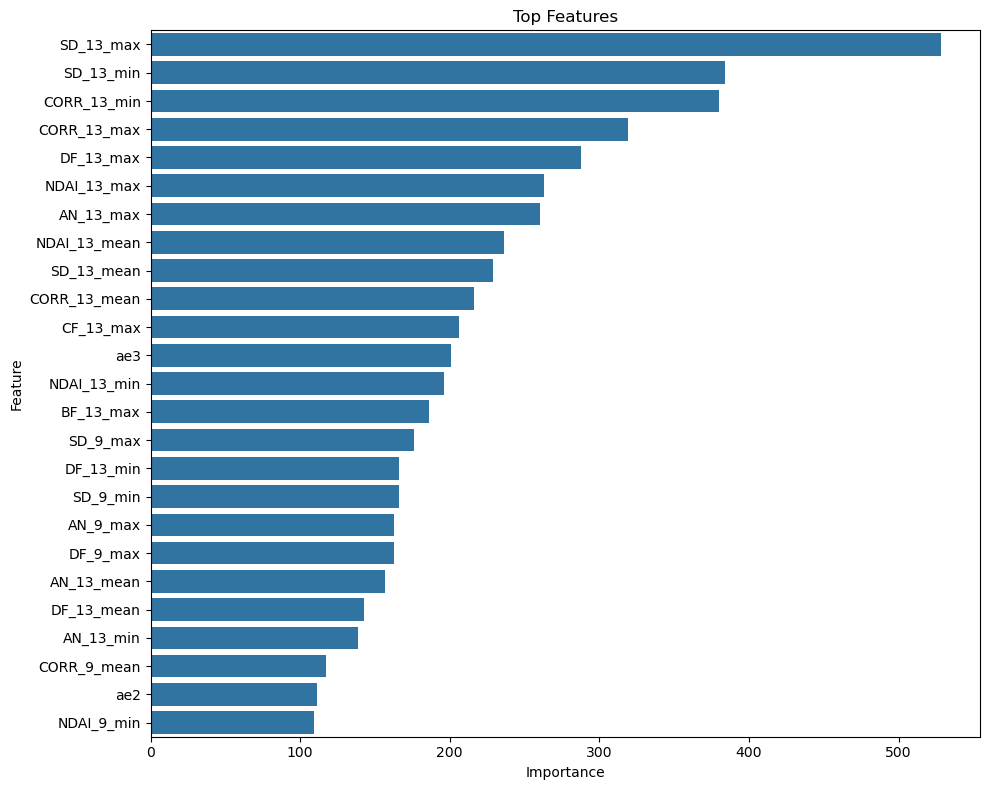

In [21]:
y_train_lgb = y_train.copy()
y_test_lgb = y_test.copy()

y_train_lgb = y_train_lgb.replace(-1, 0)
y_test_lgb = y_test_lgb.replace(-1, 0)

y_train_lgb = y_train.replace(-1, 0)
y_test_lgb = y_test.replace(-1, 0)
lgb_model_full = lgb.LGBMClassifier(**params_lgb, n_estimators=1000)
lgb_model_full.fit(X_train, y_train_lgb)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model_full.feature_importances_
}).sort_values('importance', ascending=False)


plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(25),
    x='importance',
    y='feature'
)
plt.title('Top Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top_features = feature_importance.head(15)['feature'].tolist()



In [24]:
top_features


['SD_13_max',
 'SD_13_min',
 'CORR_13_min',
 'CORR_13_max',
 'DF_13_max',
 'NDAI_13_max',
 'AN_13_max',
 'NDAI_13_mean',
 'SD_13_mean',
 'CORR_13_mean',
 'CF_13_max',
 'ae3',
 'NDAI_13_min',
 'BF_13_max',
 'SD_9_max']

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98     42830
         1.0       0.96      1.00      0.98     39253

    accuracy                           0.98     82083
   macro avg       0.98      0.98      0.98     82083
weighted avg       0.98      0.98      0.98     82083



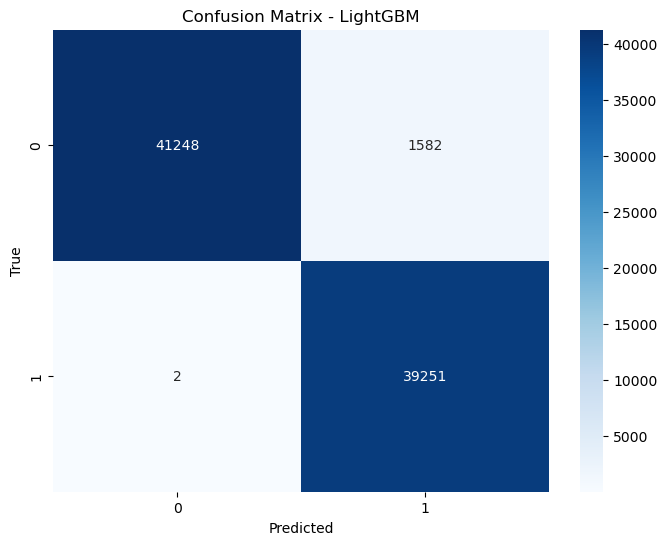

Accuracy: 0.9807024597054201


In [22]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

lgb_model = lgb.LGBMClassifier(**params_lgb, n_estimators=1000)
lgb_model.fit(X_train_top, y_train_lgb)


y_pred = lgb_model.predict(X_test_top)

print("Classification Report:")
print(classification_report(y_test_lgb, y_pred))

cm = confusion_matrix(y_test_lgb, y_pred)
plt.figure(figsize=(8, 6))
plt.title("Confusion Matrix - LightGBM")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

accuracy = accuracy_score(y_test_lgb, y_pred)
print("Accuracy:", accuracy)